# House Property Sales Forecasting using Multivariate Time Series Models

The task of this project is to perform **multivariate time series forecasting** on the *House Property Sales* dataset (2007–2019).  
The goal is to analyze historical property sales trends and build predictive models to forecast future house property prices using multiple time-dependent and feature-based variables such as property type, number of bedrooms, and location.

**Key Steps:**
- Data Preprocessing  
- Exploratory Data Analysis (EDA)  
- Feature Engineering  
- Model Implementation 
- Model Evaluation  
- Insights and Interpretation  

📈 **Objective:** To develop and compare forecasting models that accurately predict future house property prices based on historical and feature-driven data.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('raw_sales.csv')
data.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


## Preprocessing and EDA

In [3]:
df = data.copy()

In [4]:
df = data.rename(columns={'datesold':'date',
                         'propertyType':'type'})

In [5]:
df['date'] = pd.to_datetime(df['date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      29580 non-null  datetime64[ns]
 1   postcode  29580 non-null  int64         
 2   price     29580 non-null  int64         
 3   type      29580 non-null  object        
 4   bedrooms  29580 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+ MB


In [7]:
df.describe()

,date,postcode,price,bedrooms
count,29580,29580.000000,2.958000e+04,29580.000000
mean,2015-02-21 07:35:42.474645248,2730.249730,6.097363e+05,3.250169
min,2007-02-07 00:00:00,2600.000000,5.650000e+04,0.000000
25%,2013-02-05 00:00:00,2607.000000,4.400000e+05,3.000000
50%,2015-09-30 00:00:00,2615.000000,5.500000e+05,3.000000
75%,2017-07-26 00:00:00,2905.000000,7.050000e+05,4.000000
max,2019-07-27 00:00:00,2914.000000,8.000000e+06,5.000000
std,NaN,146.717292,2.817079e+05,0.951275


#### Average Price By Property Type

In [12]:
avg_price_by_type = df.groupby('type')['price'].mean().sort_values(ascending=False)
print(avg_price_by_type)

type
house    647956.128462
unit     423106.557279
Name: price, dtype: float64


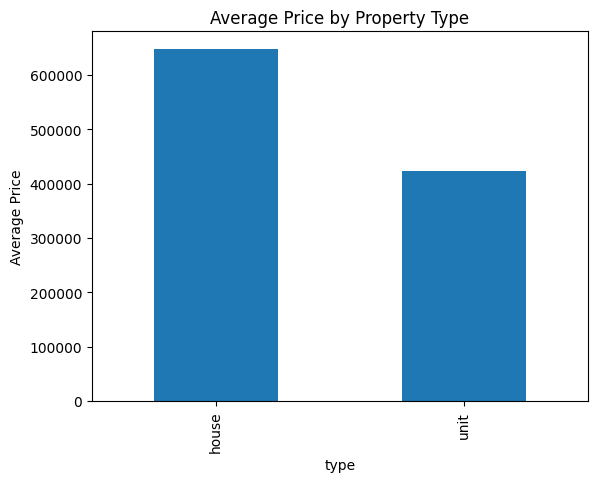

In [13]:
avg_price_by_type.plot(kind='bar', title='Average Price by Property Type')
plt.ylabel('Average Price')
plt.show()

#### Average Price by Number of Bedrooms

bedrooms
5    919056.058974
4    718171.142023
3    552304.428140
0    542300.000000
2    442222.917454
1    335992.905962
Name: price, dtype: float64


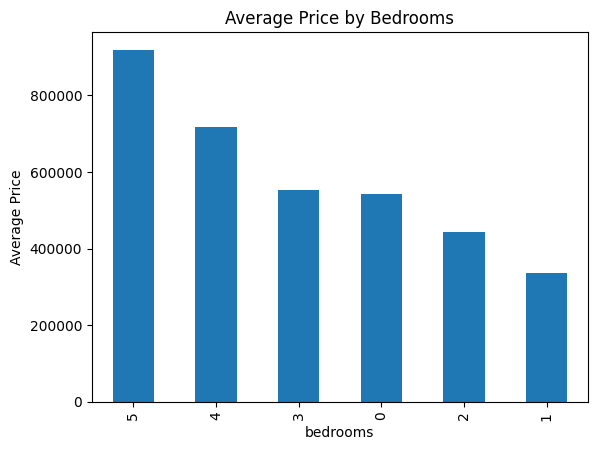

In [15]:
avg_price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_values(ascending=False)
print(avg_price_by_bedrooms)

avg_price_by_bedrooms.plot(kind='bar', title='Average Price by Bedrooms')
plt.ylabel('Average Price')
plt.show()

Here we can consider the bedroom count 0 as missing values in number of bedrooms column

#### Impute bedrooms for rows with 0 using price thresholds

In [31]:
df[df['bedrooms']==0].head()

,date,postcode,price,type,bedrooms
5801,2012-09-10,2913,415000,house,0
6484,2013-02-02,2605,840000,house,0
6497,2013-02-06,2604,490000,house,0
6917,2013-05-07,2600,725000,house,0
7167,2013-06-28,2606,630000,house,0


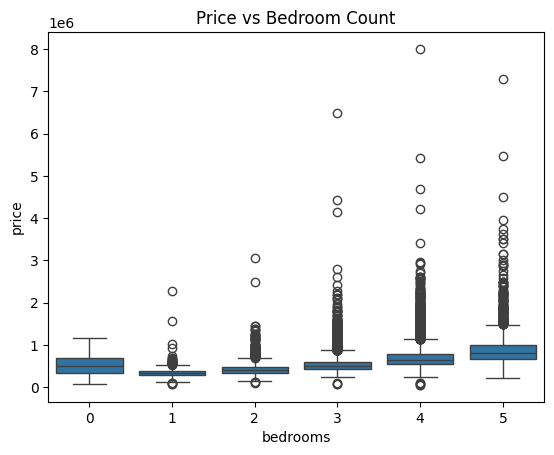

In [32]:
sns.boxplot(x='bedrooms', y='price', data=df)
plt.title('Price vs Bedroom Count')
plt.show()

In [33]:
price_stats = df.groupby('bedrooms')['price'].median()
print(price_stats)

bedrooms
0    504500.0
1    327000.0
2    410000.0
3    499000.0
4    650000.0
5    805500.0
Name: price, dtype: float64


In [45]:
# KNNImputer

from sklearn.impute import KNNImputer

df['bedrooms'] = df['bedrooms'].replace(0,np.nan)

In [46]:
df['bedrooms'].isnull().sum()

np.int64(30)

#### Average Price by Postcode

In [ ]:
avg_price_by_postcode = df.groupby('postcode')['price'].mean().sort_values(ascending=False).head(10)
print(avg_price_by_postcode)

avg_price_by_postcode.plot(kind='bar', title='Top 10 Postcodes by Average Price')
plt.ylabel('Average Price')
plt.show()


#### Correlation

In [16]:
df.corr(numeric_only=True)

,postcode,price,bedrooms
postcode,1.000000,-0.150548,0.225761
price,-0.150548,1.000000,0.484212
bedrooms,0.225761,0.484212,1.000000


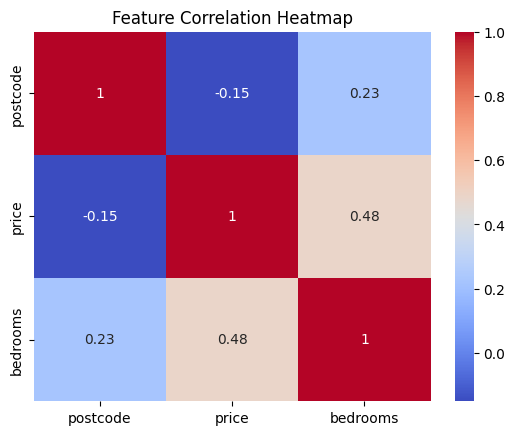

In [17]:
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()